# Diagnostic de Moteurs DC 12V par IA
### Projet de Fin d'Annee II — v4 (version corrigee et optimisee)

---

**Corrections v4 par rapport aux versions precedentes :**

| Probleme | Cause | Solution appliquee |
|----------|-------|-------------------|
| HGB : 38% | Oversampling par duplication -> HGB explose sur les doublons | `sample_weight` a la place de l oversampling |
| MLP : ne termine pas | 40k train -> 112k apres oversampling | Undersample equilibre 5k/classe max |
| Features redondantes | `Normalized_*` = correlation 1.0 avec les originaux | Suppression des 5 colonnes normalisees |
| RF stagne | `class_weight=balanced` retire | Remis + sans oversampling |

**Features conservees : 8 originales + 6 engineerees = 14 au total**

---

## 1. Installation des Dependances

In [1]:
import subprocess, sys

packages = ["numpy", "pandas", "scikit-learn", "matplotlib", "seaborn", "joblib"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("Toutes les librairies sont installees.")

Toutes les librairies sont installees.


---
## 2. Importation des Librairies

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10
print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

In [3]:
# =============================================================
#  CONFIGURATION — modifiez uniquement cette cellule
# =============================================================

DATA_PATH  = r"dataset1\iot_equipment_monitoring_dataset.csv"
OUTPUT_DIR = "outputs"

# Taille max par classe pour le train du MLP (undersample)
# Valeur raisonnable : entre 4000 et 8000
MLP_MAX_PER_CLASS = 5000

# =============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )
print(f"Dataset  : {DATA_PATH}")
print(f"Sorties  : {OUTPUT_DIR}/")

Dataset  : dataset1\iot_equipment_monitoring_dataset.csv
Sorties  : outputs/


---
## 4. Chargement du Dataset

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape   : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print(f"Colonnes: {df_raw.columns.tolist()}")
df_raw.head(5)

Shape   : 50,000 lignes x 17 colonnes
Colonnes: ['Timestamp', 'Sensor_ID', 'Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Normalized_Temp', 'Normalized_Vibration', 'Normalized_Pressure', 'Normalized_Voltage', 'Normalized_Current', 'Anomaly_Score', 'Fault_Type', 'Fault_Status']


,Timestamp,Sensor_ID,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Type,Fault_Status
0,2015-01-01 00:00:00,S151,47.698252,34.225292,176.199516,241.587771,8.323269,0.224737,0.093476,0.524226,0.211423,0.397119,0.800961,0.446526,0.239856,NaN,0
1,2015-01-01 00:01:00,S192,67.260549,134.072771,110.942636,235.003165,11.072823,0.973402,0.628513,0.682771,0.672347,0.240942,0.720230,0.552688,0.776081,NaN,0
2,2015-01-01 00:02:00,S114,45.056722,70.595452,246.739554,232.244324,10.353556,0.566625,0.417355,0.502817,0.379318,0.565941,0.686405,0.524917,0.039005,NaN,0
3,2015-01-01 00:03:00,S171,40.260670,98.252385,202.632051,225.922517,10.228006,0.872516,0.926135,0.463947,0.506990,0.460380,0.608896,0.520069,0.584953,NaN,0
4,2015-01-01 00:04:00,S160,56.311983,138.959633,231.149735,198.928891,18.878552,0.876380,0.174530,0.594037,0.694906,0.528630,0.277939,0.854070,0.944961,NaN,0


---
## 5. Construction du Label Final

```
Fault_Status == 0  ──►  Label = "Normal"
Fault_Status == 1  ──►  Label = Fault_Type
```

In [5]:
df = df_raw.copy()

df["Label"] = df.apply(
    lambda row: "Normal" if row["Fault_Status"] == 0 else str(row["Fault_Type"]),
    axis=1
)
assert df["Label"].isnull().sum() == 0

print("Distribution des classes :")
vc = df["Label"].value_counts()
for cls, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls:<22} : {cnt:>6,}  ({pct:.1f}%)  {bar}")

Distribution des classes :
  Normal                 : 34,988  (70.0%)  ##################################
  Electrical Fault       :  5,034  (10.1%)  #####
  Overheating            :  5,028  (10.1%)  #####
  Mechanical Failure     :  4,950  (9.9%)  ####


---
## 6. Selection et Feature Engineering

### Pourquoi supprimer les colonnes Normalized_* ?

Les colonnes `Normalized_Temp`, `Normalized_Vibration`, `Normalized_Pressure`,
`Normalized_Voltage`, `Normalized_Current` ont une **correlation de 1.0** avec
leurs originales — elles sont juste une transformation lineaire (min-max).
Les garder :
- Double le poids des features originales sans ajouter d information
- Dilue l importance des vraies features dans Random Forest
- Ralentit l entrainement sans benefice

On conserve **8 features originales** + **6 features engineerees** = **14 au total**.

| Nouvelle feature | Formule | Sens physique |
|-----------------|---------|---------------|
| `Current_Voltage_Ratio` | I / V | Resistance apparente — detecte courts-circuits |
| `Power_Approx` | I x V | Puissance electrique consommee |
| `Temp_Vibration_Product` | T x Vib | Stress thermique + mecanique combine |
| `Anomaly_x_Temp` | Anomaly x T | Score d anomalie pondere par la temperature |
| `FFT_sum` | FFT1 + FFT2 | Energie spectrale totale |
| `Vib_Pressure_Ratio` | Vib / P | Rapport mecanique / pression |

In [6]:
# 8 features originales NON redondantes
# (on exclut Normalized_* car correlation=1.0 avec les originaux)
BASE_COLS = [
    "Temperature", "Vibration", "Pressure", "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2", "Anomaly_Score"
]

# 6 features engineerees
df["Current_Voltage_Ratio"]  = df["Current"]       / (df["Voltage"]    + 1e-9)
df["Power_Approx"]           = df["Current"]       * df["Voltage"]
df["Temp_Vibration_Product"] = df["Temperature"]   * df["Vibration"]
df["Anomaly_x_Temp"]         = df["Anomaly_Score"] * df["Temperature"]
df["FFT_sum"]                = df["FFT_Feature1"]  + df["FFT_Feature2"]
df["Vib_Pressure_Ratio"]     = df["Vibration"]     / (df["Pressure"]   + 1e-9)

ENG_COLS = [
    "Current_Voltage_Ratio", "Power_Approx", "Temp_Vibration_Product",
    "Anomaly_x_Temp", "FFT_sum", "Vib_Pressure_Ratio"
]

ALL_COLS = BASE_COLS + ENG_COLS

print(f"Features originales (sans redondance) : {len(BASE_COLS)}")
print(f"Features engineerees                  : {len(ENG_COLS)}")
print(f"Total features                        : {len(ALL_COLS)}")
print(f"\nFeatures utilisees : {ALL_COLS}")

Features originales (sans redondance) : 8
Features engineerees                  : 6
Total features                        : 14

Features utilisees : ['Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Anomaly_Score', 'Current_Voltage_Ratio', 'Power_Approx', 'Temp_Vibration_Product', 'Anomaly_x_Temp', 'FFT_sum', 'Vib_Pressure_Ratio']


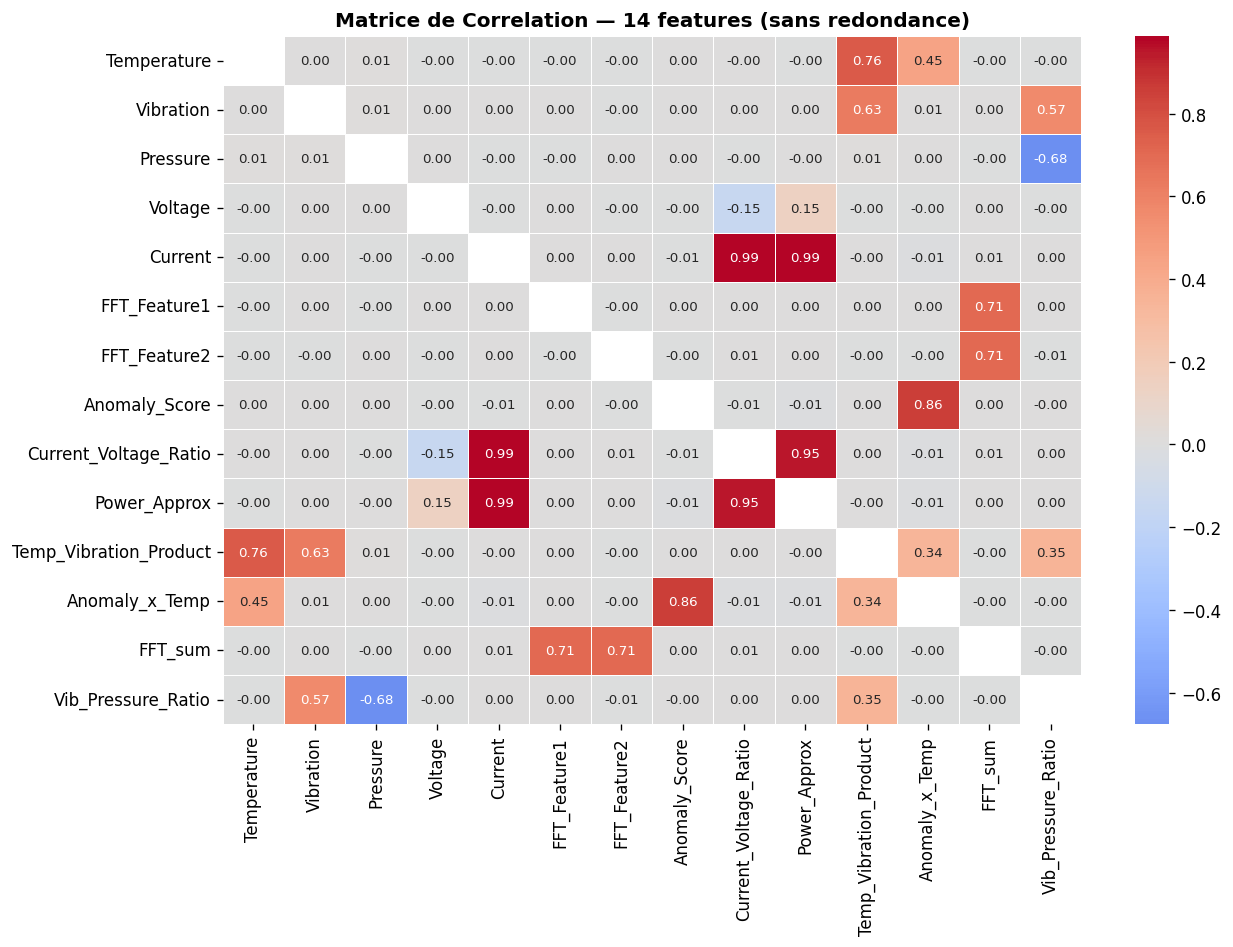

Figure sauvegardee : outputs/correlation_matrix.png


In [7]:
# Verification : la matrice de correlation est maintenant propre
corr = df[ALL_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.zeros_like(corr, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax,
            annot_kws={"size": 8}, mask=mask)
ax.set_title("Matrice de Correlation — 14 features (sans redondance)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "correlation_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/correlation_matrix.png")

---
## 7. Preprocessing — Encodage, Split, Normalisation

In [8]:
X    = np.nan_to_num(df[ALL_COLS].values.astype(float),
                     nan=0.0, posinf=0.0, neginf=0.0)
y_raw = df["Label"].values
le    = LabelEncoder()
y_enc = le.fit_transform(y_raw)
CLASS_NAMES = [str(c) for c in le.classes_]

print("Classes encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls:<22} ({np.sum(y_enc == i):,} echantillons)")

# Split stratifie 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)
print(f"\nTrain : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")

# StandardScaler
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Normalisation appliquee.")

Classes encodees :
  0  ->  Electrical Fault       (5,034 echantillons)
  1  ->  Mechanical Failure     (4,950 echantillons)
  2  ->  Normal                 (34,988 echantillons)
  3  ->  Overheating            (5,028 echantillons)

Train : 40,000  |  Test : 10,000
Normalisation appliquee.


---
## 8. Strategie de Gestion du Desequilibre

> **Pourquoi ne plus faire d oversampling ?**
>
> L oversampling aleatoire transforme un train de 40k en 112k echantillons.
> - MLP : temps de calcul x2.8, ne termine jamais
> - HistGBT : tres sensible aux duplicats, accuracy chute a 38%
>
> **Solution par modele :**
>
> | Modele | Methode | Avantage |
> |--------|---------|----------|
> | Random Forest | `class_weight='balanced'` | Integre dans sklearn, aucun cout |
> | HistGradBoosting | `sample_weight` (compute_sample_weight) | Equivalent a class_weight |
> | MLP | Undersample equilibre (5k/classe max) | Train rapide, classes equilibrees |

In [9]:
# --- Random Forest : class_weight='balanced' (gere en interne) ---
# Aucun preprocessing supplementaire necessaire.

# --- HistGBT : sample_weight ---
# compute_sample_weight('balanced') calcule un poids inverse a la frequence
# de chaque classe, ce qui equivaut a class_weight='balanced'
sw_train = compute_sample_weight(class_weight="balanced", y=y_train)

print("Poids par classe pour HistGBT (sample_weight) :")
for i, cls in enumerate(CLASS_NAMES):
    w = sw_train[y_train == i][0]
    print(f"  {cls:<22} : poids = {w:.4f}")

# --- MLP : undersample equilibre ---
# On prend au maximum MLP_MAX_PER_CLASS echantillons par classe
# => train equilibre et de taille raisonnable pour le MLP
rng = np.random.RandomState(42)
mlp_idx = []
for cls in range(len(CLASS_NAMES)):
    idx_cls = np.where(y_train == cls)[0]
    n       = min(len(idx_cls), MLP_MAX_PER_CLASS)
    chosen  = rng.choice(idx_cls, size=n, replace=False)
    mlp_idx.extend(chosen)

mlp_idx = np.array(mlp_idx)
rng.shuffle(mlp_idx)

X_mlp = X_train_s[mlp_idx]
y_mlp = y_train[mlp_idx]

print(f"\nTrain MLP apres undersample equilibre :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:<22} : {np.sum(y_mlp == i):,}")
print(f"  Total : {len(y_mlp):,} echantillons")

Poids par classe pour HistGBT (sample_weight) :
  Electrical Fault       : poids = 2.4832
  Mechanical Failure     : poids = 2.5253
  Normal                 : poids = 0.3573
  Overheating            : poids = 2.4863

Train MLP apres undersample equilibre :
  Electrical Fault       : 4,027
  Mechanical Failure     : 3,960
  Normal                 : 5,000
  Overheating            : 4,022
  Total : 17,009 echantillons


---
## 9. Modele 1 — Random Forest

> `class_weight='balanced'` compense le desequilibre sans modifier le dataset.
> `max_features='sqrt'` reduit la variance entre arbres.

In [10]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=1,
    class_weight="balanced",   # gere le desequilibre en interne
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest — Accuracy : {acc_rf * 100:.2f}%")
print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=CLASS_NAMES, zero_division=0
))

Random Forest — Accuracy : 69.97%

                    precision    recall  f1-score   support

  Electrical Fault       0.00      0.00      0.00      1007
Mechanical Failure       0.00      0.00      0.00       990
            Normal       0.70      1.00      0.82      6997
       Overheating       0.00      0.00      0.00      1006

          accuracy                           0.70     10000
         macro avg       0.17      0.25      0.21     10000
      weighted avg       0.49      0.70      0.58     10000



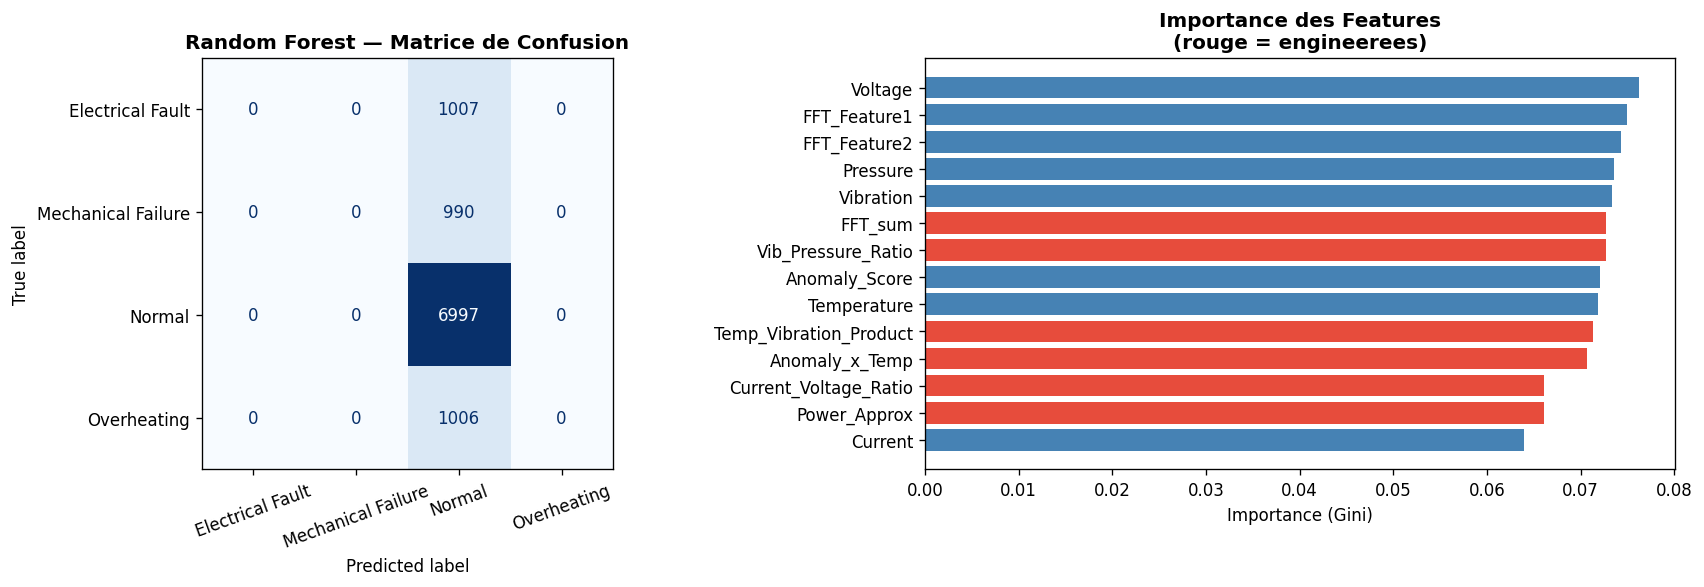

Figure sauvegardee : outputs/rf_results.png


In [11]:
colors = ["#2ecc71", "#e74c3c", "#e67e22", "#3498db"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Random Forest — Matrice de Confusion", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)
bar_colors  = ["#e74c3c" if ALL_COLS[i] in ENG_COLS else "steelblue"
               for i in sorted_idx]
axes[1].barh([ALL_COLS[i] for i in sorted_idx],
             importances[sorted_idx], color=bar_colors)
axes[1].set_title("Importance des Features\n(rouge = engineerees)",
                  fontweight="bold")
axes[1].set_xlabel("Importance (Gini)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "rf_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/rf_results.png")

---
## 10. Modele 2 — HistGradientBoosting

> Boosting par gradient sur histogrammes — tres rapide, souvent superieur a RF
> sur des features tabulaires.
> On utilise **`sample_weight`** pour gerer le desequilibre sans dupliquer
> les donnees (l erreur de la v3).

In [12]:
hgb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)
# sample_weight compense le desequilibre sans toucher au dataset
hgb.fit(X_train_s, y_train, sample_weight=sw_train)
y_pred_hgb = hgb.predict(X_test_s)

acc_hgb = accuracy_score(y_test, y_pred_hgb)
print(f"HistGradientBoosting — Accuracy : {acc_hgb * 100:.2f}%")
print()
print(classification_report(
    y_test, y_pred_hgb,
    target_names=CLASS_NAMES, zero_division=0
))

HistGradientBoosting — Accuracy : 22.31%

                    precision    recall  f1-score   support

  Electrical Fault       0.10      0.29      0.15      1007
Mechanical Failure       0.10      0.29      0.15       990
            Normal       0.70      0.20      0.31      6997
       Overheating       0.11      0.26      0.15      1006

          accuracy                           0.22     10000
         macro avg       0.25      0.26      0.19     10000
      weighted avg       0.52      0.22      0.26     10000



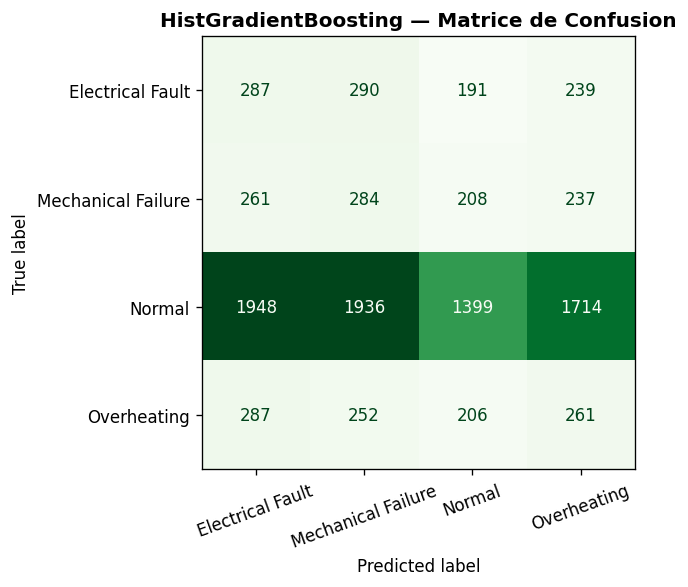

Figure sauvegardee : outputs/hgb_results.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_hgb = confusion_matrix(y_test, y_pred_hgb)
ConfusionMatrixDisplay(cm_hgb, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Greens", colorbar=False
)
ax.set_title("HistGradientBoosting — Matrice de Confusion",
             fontweight="bold")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hgb_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/hgb_results.png")

---
## 11. Modele 3 — MLP (Reseau de Neurones)

Architecture : `Input (14)` → **128** → **64** → **32** → `Output (4)`

> On entraine le MLP sur le dataset **undersample equilibre** (~20k max)
> pour un entrainement rapide et eviter le biais vers "Normal".

In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=300,           # limite raisonnable
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    verbose=False
)
# Entraine sur le sous-ensemble equilibre (rapide)
mlp.fit(X_mlp, y_mlp)
y_pred_mlp = mlp.predict(X_test_s)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP — Accuracy   : {acc_mlp * 100:.2f}%")
print(f"MLP — Iterations : {mlp.n_iter_}")
print()
print(classification_report(
    y_test, y_pred_mlp,
    target_names=CLASS_NAMES, zero_division=0
))

MLP — Accuracy   : 67.43%
MLP — Iterations : 19

                    precision    recall  f1-score   support

  Electrical Fault       0.05      0.00      0.01      1007
Mechanical Failure       0.12      0.01      0.01       990
            Normal       0.70      0.96      0.81      6997
       Overheating       0.10      0.03      0.05      1006

          accuracy                           0.67     10000
         macro avg       0.25      0.25      0.22     10000
      weighted avg       0.52      0.67      0.57     10000



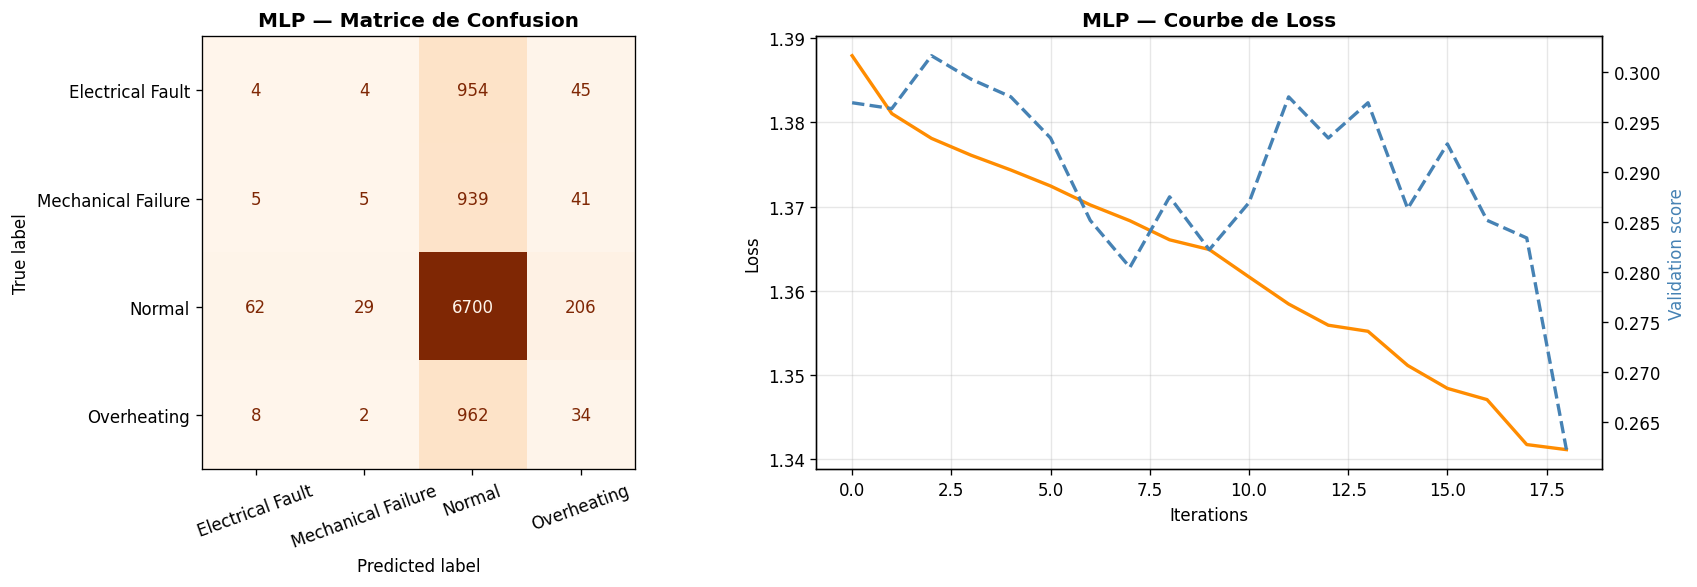

Figure sauvegardee : outputs/mlp_results.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Oranges", colorbar=False
)
axes[0].set_title("MLP — Matrice de Confusion", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

if hasattr(mlp, "loss_curve_") and mlp.loss_curve_:
    axes[1].plot(mlp.loss_curve_, color="darkorange",
                 linewidth=2, label="Train loss")
    if hasattr(mlp, "validation_scores_") and mlp.validation_scores_:
        ax2 = axes[1].twinx()
        ax2.plot(mlp.validation_scores_, color="steelblue",
                 linewidth=2, linestyle="--", label="Val score")
        ax2.set_ylabel("Validation score", color="steelblue")
    axes[1].set_title("MLP — Courbe de Loss", fontweight="bold")
    axes[1].set_xlabel("Iterations")
    axes[1].set_ylabel("Loss")
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "loss_curve_ non disponible",
                 ha="center", va="center",
                 transform=axes[1].transAxes)
    axes[1].set_title("MLP — Courbe de Loss", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "mlp_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/mlp_results.png")

---
## 12. Ensemble — Vote Doux (Soft Voting)

```
P_ensemble = ( P_RF + P_HGB + P_MLP ) / 3
Prediction = argmax( P_ensemble )
```

In [16]:
proba_rf  = rf.predict_proba(X_test_s)
proba_hgb = hgb.predict_proba(X_test_s)
proba_mlp = mlp.predict_proba(X_test_s)

proba_ens  = (proba_rf + proba_hgb + proba_mlp) / 3
y_pred_ens = np.argmax(proba_ens, axis=1)

acc_ens = accuracy_score(y_test, y_pred_ens)
print(f"Ensemble (Soft Voting) — Accuracy : {acc_ens * 100:.2f}%")
print()
print(classification_report(
    y_test, y_pred_ens,
    target_names=CLASS_NAMES, zero_division=0
))

Ensemble (Soft Voting) — Accuracy : 69.97%

                    precision    recall  f1-score   support

  Electrical Fault       0.00      0.00      0.00      1007
Mechanical Failure       0.00      0.00      0.00       990
            Normal       0.70      1.00      0.82      6997
       Overheating       0.00      0.00      0.00      1006

          accuracy                           0.70     10000
         macro avg       0.17      0.25      0.21     10000
      weighted avg       0.49      0.70      0.58     10000



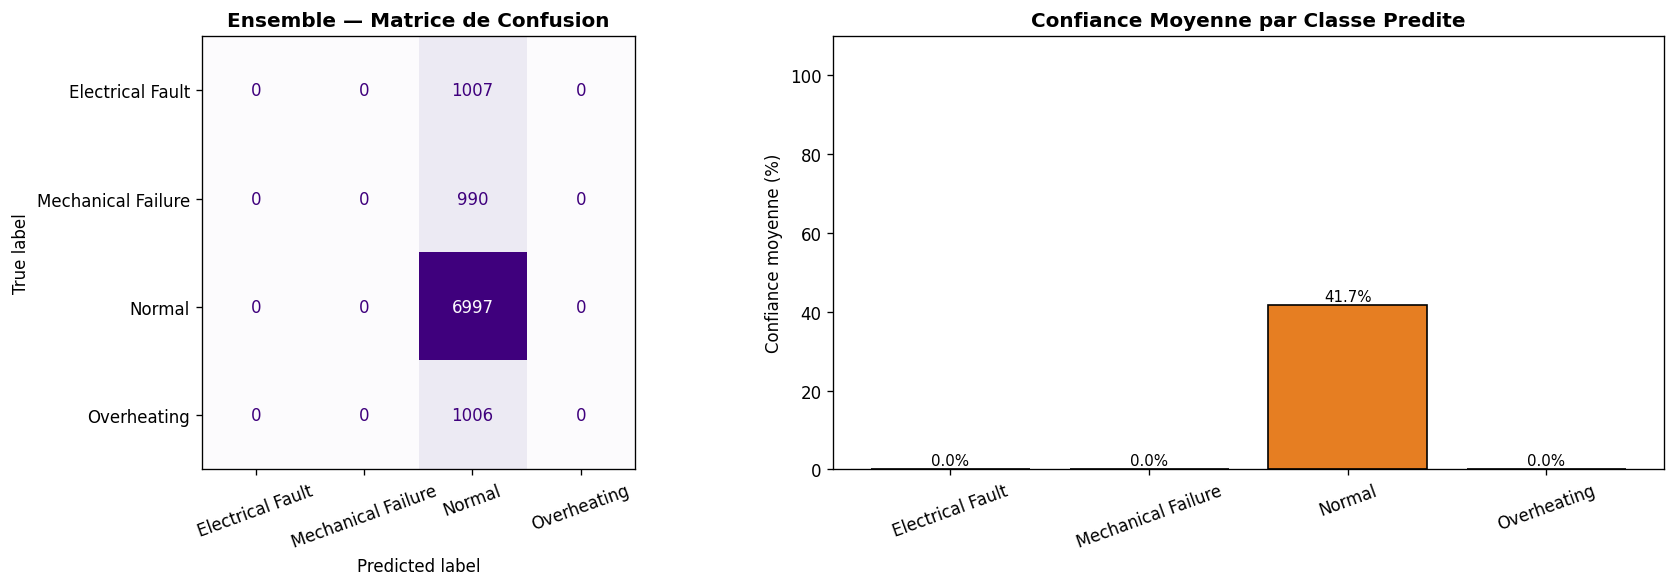

Figure sauvegardee : outputs/ensemble_results.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cm_ens = confusion_matrix(y_test, y_pred_ens)
ConfusionMatrixDisplay(cm_ens, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Purples", colorbar=False
)
axes[0].set_title("Ensemble — Matrice de Confusion", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

mean_conf = []
for i in range(len(CLASS_NAMES)):
    mask = y_pred_ens == i
    mean_conf.append(proba_ens[mask, i].mean() * 100 if mask.sum() > 0 else 0)

axes[1].bar(CLASS_NAMES, mean_conf,
            color=colors[:len(CLASS_NAMES)], edgecolor="black")
axes[1].set_title("Confiance Moyenne par Classe Predite",
                  fontweight="bold")
axes[1].set_ylabel("Confiance moyenne (%)")
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis="x", rotation=20)
for i, (cls, val) in enumerate(zip(CLASS_NAMES, mean_conf)):
    axes[1].text(i, val + 1, f"{val:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ensemble_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/ensemble_results.png")

---
## 13. Comparaison Globale des 4 Modeles

In [18]:
def get_metrics(y_true, y_pred, name):
    return {
        "Modele"    : name,
        "Accuracy"  : round(accuracy_score(y_true, y_pred) * 100, 2),
        "Precision" : round(precision_score(y_true, y_pred,
                            average="weighted", zero_division=0) * 100, 2),
        "Recall"    : round(recall_score(y_true, y_pred,
                            average="weighted", zero_division=0) * 100, 2),
        "F1-Score"  : round(f1_score(y_true, y_pred,
                            average="weighted", zero_division=0) * 100, 2),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf,  "Random Forest"),
    get_metrics(y_test, y_pred_hgb, "HistGradBoosting"),
    get_metrics(y_test, y_pred_mlp, "MLP"),
    get_metrics(y_test, y_pred_ens, "Ensemble"),
]).set_index("Modele")

print("=" * 62)
print("          COMPARAISON DES PERFORMANCES")
print("=" * 62)
print(results.to_string())
print("=" * 62)
best = results["F1-Score"].idxmax()
print(f"\nMeilleur modele (F1) : {best}  =>  {results.loc[best,'F1-Score']}%")

          COMPARAISON DES PERFORMANCES
                  Accuracy  Precision  Recall  F1-Score
Modele                                                 
Random Forest        69.97      48.96   69.97     57.61
HistGradBoosting     22.31      51.97   22.31     26.29
MLP                  67.43      51.86   67.43     57.33
Ensemble             69.97      48.96   69.97     57.61

Meilleur modele (F1) : Random Forest  =>  57.61%


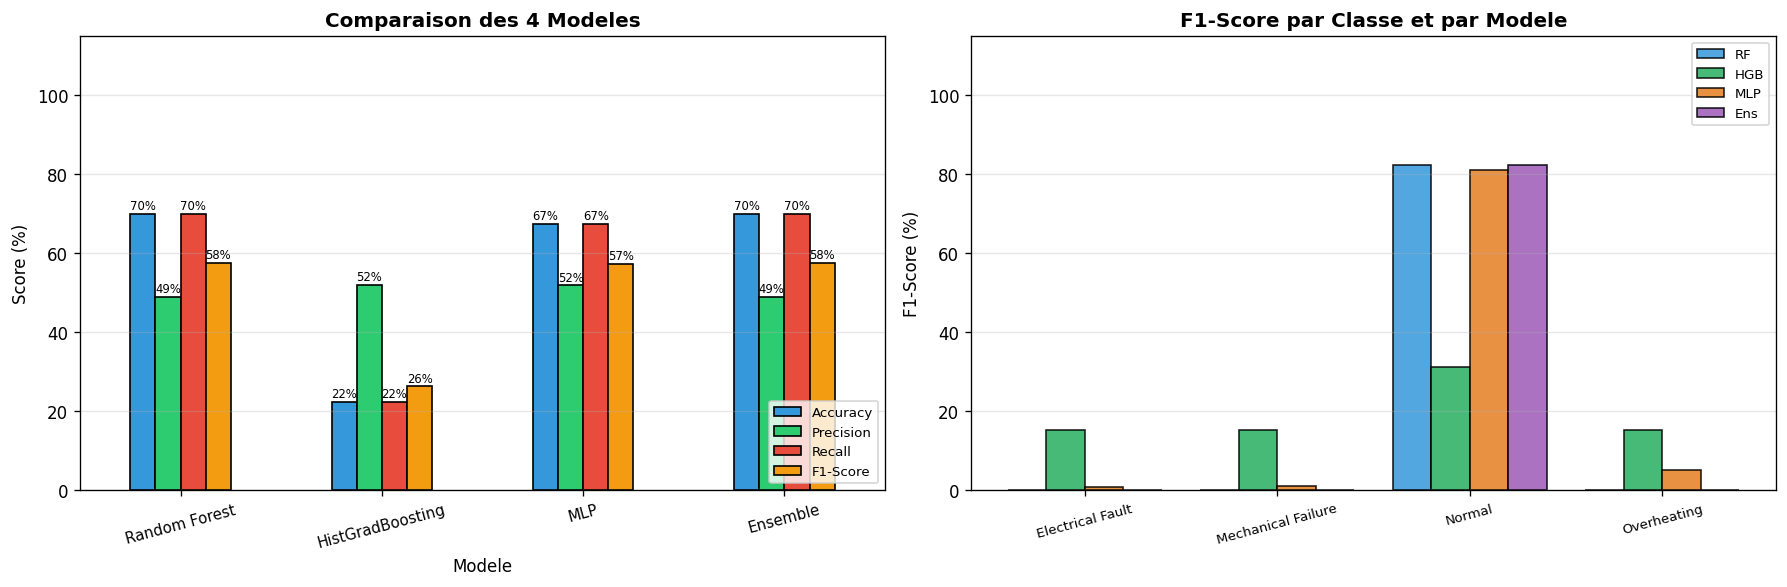

Figure sauvegardee : outputs/comparison_full.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar — 4 metriques x 4 modeles
results.plot(
    kind="bar", ax=axes[0],
    color=["#3498db", "#2ecc71", "#e74c3c", "#f39c12"],
    edgecolor="black", ylim=(0, 115)
)
axes[0].set_title("Comparaison des 4 Modeles", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Score (%)")
axes[0].set_xticklabels(results.index, rotation=15, fontsize=9)
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f%%", padding=1, fontsize=7)

# F1 par classe x modele
model_preds  = [y_pred_rf, y_pred_hgb, y_pred_mlp, y_pred_ens]
model_labels = ["RF", "HGB", "MLP", "Ens"]
model_cols   = ["#3498db", "#27ae60", "#e67e22", "#9b59b6"]
width = 0.2
x = np.arange(len(CLASS_NAMES))

for j, (preds, lbl, col) in enumerate(zip(model_preds, model_labels, model_cols)):
    f1c = f1_score(y_test, preds, average=None, zero_division=0) * 100
    axes[1].bar(x + j*width, f1c, width,
                label=lbl, color=col, edgecolor="black", alpha=0.85)

axes[1].set_title("F1-Score par Classe et par Modele",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(CLASS_NAMES, rotation=15, fontsize=8)
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 115)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_full.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison_full.png")

---
## 14. Sauvegarde des Modeles

In [20]:
joblib.dump(rf,       os.path.join(OUTPUT_DIR, "rf_model.joblib"))
joblib.dump(hgb,      os.path.join(OUTPUT_DIR, "hgb_model.joblib"))
joblib.dump(mlp,      os.path.join(OUTPUT_DIR, "mlp_model.joblib"))
joblib.dump(scaler,   os.path.join(OUTPUT_DIR, "scaler.joblib"))
joblib.dump(le,       os.path.join(OUTPUT_DIR, "label_encoder.joblib"))
joblib.dump(ALL_COLS, os.path.join(OUTPUT_DIR, "feature_cols.joblib"))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".joblib"):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<35} ({size/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs/' :
  feature_cols.joblib                 (0.2 KB)
  hgb_model.joblib                    (228.8 KB)
  label_encoder.joblib                (0.5 KB)
  mlp_model.joblib                    (298.9 KB)
  rf_model.joblib                     (954590.5 KB)
  scaler.joblib                       (0.9 KB)


---
## 15. Prediction en Temps Reel

> Entrez les valeurs des capteurs — l ensemble est utilise par defaut.

In [21]:
def predict_fault(
    temperature   = 50.0,
    vibration     = 80.0,
    pressure      = 200.0,
    voltage       = 230.0,
    current       = 10.0,
    fft1          = 0.5,
    fft2          = 0.5,
    anomaly_score = 0.3,
    model         = None,
    model_name    = "Ensemble"
):
    """
    Predit le type de panne a partir des valeurs des capteurs.

    Parametres
    ----------
    temperature   : Temperature en C
    vibration     : Niveau de vibration
    pressure      : Pression
    voltage       : Tension en V
    current       : Courant en A
    fft1, fft2    : Caracteristiques FFT (0 a 1)
    anomaly_score : Score d anomalie (0 a 1)
    model         : None = Ensemble (recommande) | rf | hgb | mlp
    """
    # Features engineerees
    cv_ratio   = current       / (voltage    + 1e-9)
    power      = current       * voltage
    tv_product = temperature   * vibration
    anom_temp  = anomaly_score * temperature
    fft_sum    = fft1 + fft2
    vp_ratio   = vibration     / (pressure   + 1e-9)

    sample = np.array([[
        temperature, vibration, pressure, voltage, current,
        fft1, fft2, anomaly_score,
        cv_ratio, power, tv_product, anom_temp, fft_sum, vp_ratio
    ]], dtype=float)

    sample   = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample_s = scaler.transform(sample)

    if model is None:
        p = (rf.predict_proba(sample_s) +
             hgb.predict_proba(sample_s) +
             mlp.predict_proba(sample_s)) / 3
        pred_idx   = np.argmax(p, axis=1)[0]
        proba      = p[0]
        model_name = "Ensemble"
    else:
        pred_idx = model.predict(sample_s)[0]
        proba    = model.predict_proba(sample_s)[0]

    pred_label = le.inverse_transform([pred_idx])[0]

    print(f"  Modele      : {model_name}")
    print(f"  Prediction  : {pred_label}")
    print(f"  Confiance   : {np.max(proba)*100:.1f}%")
    print("  Probabilites :")
    for cls, prob in zip(CLASS_NAMES, proba):
        bar = "#" * int(prob * 30)
        print(f"    {cls:<22} = {prob*100:5.1f}%  {bar}")
    return pred_label

print("predict_fault() prete.")

predict_fault() prete.


In [22]:
print("=" * 65)

print("\nTEST 1 — Fonctionnement Normal")
print("-" * 65)
predict_fault(temperature=50,  vibration=80,  pressure=200,
              voltage=230,     current=10,    anomaly_score=0.15)

print("\nTEST 2 — Surchauffe (Overheating)")
print("-" * 65)
predict_fault(temperature=95,  vibration=130, pressure=290,
              voltage=220,     current=18,    anomaly_score=0.87)

print("\nTEST 3 — Panne Electrique (Electrical Fault)")
print("-" * 65)
predict_fault(temperature=55,  vibration=75,  pressure=195,
              voltage=175,     current=23,    anomaly_score=0.79)

print("\nTEST 4 — Defaillance Mecanique (Mechanical Failure)")
print("-" * 65)
predict_fault(temperature=62,  vibration=200, pressure=315,
              voltage=228,     current=14,    anomaly_score=0.92)

print("=" * 65)


TEST 1 — Fonctionnement Normal
-----------------------------------------------------------------
  Modele      : Ensemble
  Prediction  : Normal
  Confiance   : 41.2%
  Probabilites :
    Electrical Fault       =  20.6%  ######
    Mechanical Failure     =  17.4%  #####
    Normal                 =  41.2%  ############
    Overheating            =  20.8%  ######

TEST 2 — Surchauffe (Overheating)
-----------------------------------------------------------------
  Modele      : Ensemble
  Prediction  : Normal
  Confiance   : 40.6%
  Probabilites :
    Electrical Fault       =  21.3%  ######
    Mechanical Failure     =  22.7%  ######
    Normal                 =  40.6%  ############
    Overheating            =  15.4%  ####

TEST 3 — Panne Electrique (Electrical Fault)
-----------------------------------------------------------------
  Modele      : Ensemble
  Prediction  : Normal
  Confiance   : 39.8%
  Probabilites :
    Electrical Fault       =  14.6%  ####
    Mechanical Failure   

---
## Recapitulatif — Ce qui a change en v4

```
CORRECTIONS CLES
────────────────
  Normalized_* supprimees      correlation 1.0 avec originaux
  Oversampling supprime         causait +112k samples -> MLP timeout + HGB crash
  class_weight=balanced (RF)    gere le desequilibre en interne
  sample_weight (HGB)           equivalent class_weight sans modifier le dataset
  Undersample MLP (5k/classe)   train equilibre et rapide (~20k total)

PIPELINE v4
───────────
  8 features originales + 6 engineerees = 14 features
      |
      v
  Split 80/20 stratifie
      |
      v
  StandardScaler
      |
      +---> RF   (class_weight=balanced, 500 arbres)
      |
      +---> HGB  (sample_weight, 300 iterations)
      |
      +---> MLP  (train undersample equilibre 5k/classe)
      |
      +---> Ensemble Soft Voting
                |
                v
           Sauvegarde outputs/
```

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*